<a href="https://colab.research.google.com/github/Chrisbarbosa711/CSC360researchProject-RAGLLMs/blob/main/Baseline-Models/rag_energy_accuracy_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG Model Energy–Latency–Accuracy Benchmark

This notebook compares multiple RAG-based LLM systems (e.g., PIKE-RAG, LangChain RAG, HF Baseline RAG) along three axes:

**Metrics**:
- Energy per query (Joules / Wh)
- Latency per query (seconds)
- Accuracy on domain-specific QA tasks (EM, F1)

**Purpose**:
- Compare performance vs energy trade-offs
- Identify efficient (possibly distributed) RAG approaches


## 1. Setup & Imports

In [1]:
!pip install -q --upgrade langchain langchain_community openai faiss-cpu sentence-transformers transformers datasets tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.9/475.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [41]:
import os
import time
import json
import re
import torch
import numpy as np
from tqdm import tqdm
import requests
from datasets import Dataset, load_dataset
from getpass import getpass
from sentence_transformers import SentenceTransformer
import faiss
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from transformers import RagTokenizer, RagRetriever, RagSequenceForGeneration, DPRContextEncoder, DPRContextEncoderTokenizer

from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_classic.chains.retrieval_qa.base import RetrievalQA
from langchain_community.llms import HuggingFacePipeline

try:
    import pynvml
    pynvml.nvmlInit()
    NVML_AVAILABLE = True
except:
    NVML_AVAILABLE = False

try:
    import pyRAPL
    pyRAPL.setup()
    PYRAPL_AVAILABLE = True
except:
    PYRAPL_AVAILABLE = False

In [42]:
hf_token = getpass("Enter your Hugging Face API token: ")
os.environ["HUGGINGFACEHUB_API_TOKEN"] = hf_token

def check_hf_token(token):
    headers = {"Authorization": f"Bearer {token}"}
    # Test access to Hugging Face Hub
    test_url = "https://huggingface.co/api/whoami-v2"
    try:
        r = requests.get(test_url, headers=headers)
        if r.status_code == 200:
            user = r.json().get("name") or r.json().get("user")
            print(f"✅ Hugging Face token is valid. Logged in as: {user}")
            return True
        else:
            print(f"❌ Hugging Face token invalid (status code {r.status_code})")
            return False
    except Exception as e:
        print(f"❌ Error checking token: {e}")
        return False

if not check_hf_token(hf_token):
    raise ValueError("Invalid Hugging Face token. Please try again.")

Enter your Hugging Face API token: ··········
✅ Hugging Face token is valid. Logged in as: sdemetriusjenkins


## 2. Utility Functions (Accuracy Metrics)

In [5]:
def normalize_text(s):
    s = s.lower()
    s = re.sub(r'[^a-z0-9 ]', '', s)
    return re.sub(r'\s+', ' ', s).strip()

def exact_match(pred, truth):
    return int(normalize_text(pred) == normalize_text(truth))

def f1_score(pred, truth):
    p = normalize_text(pred).split()
    t = normalize_text(truth).split()
    if not p or not t: return 0.0
    common = set(p) & set(t)
    if not common: return 0.0
    precision = len(common) / len(p)
    recall = len(common) / len(t)
    return 2 * precision * recall / (precision + recall)

## 3. Retrieval Index (FAISS)

In [6]:
class Retriever:
    def __init__(self, model='all-MiniLM-L6-v2'):
        self.encoder = SentenceTransformer(model)
        self.index = None
        self.docs = []

    def build(self, docs):
        self.docs = docs
        emb = self.encoder.encode(docs, convert_to_numpy=True)
        faiss.normalize_L2(emb)
        self.index = faiss.IndexFlatIP(emb.shape[1])
        self.index.add(emb)

    def retrieve(self, query, k=5):
        q = self.encoder.encode([query], convert_to_numpy=True)
        faiss.normalize_L2(q)
        _, I = self.index.search(q, k)
        return [self.docs[i] for i in I[0]]

## 4. RAG Runners (HF Baseline, LangChain-style, PIKE-RAG Placeholder)

In [7]:
class RAGRunner:
    def __init__(self, name, generator):
        self.name = name
        self.generator = generator

    def run(self, query, docs):
        prompt = query + '\n' + '\n'.join(docs[:3])
        t0 = time.time()
        energy = 0.0
        if NVML_AVAILABLE:
            h = pynvml.nvmlDeviceGetHandleByIndex(0)
            p0 = pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0
        out = self.generator(prompt)
        latency = time.time() - t0
        if NVML_AVAILABLE:
            p1 = pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0
            energy = (p0 + p1) / 2 * latency
        return out, latency, energy

## 5. Dataset Loading

In [9]:
ds = load_dataset('FreedomIntelligence/RAG-Instruct', split='train[:500]')
queries = [x['question'] for x in ds]
answers = [x['answer'][0] if isinstance(x['answer'], list) else x['answer'] for x in ds]
docs = []
for x in ds:
    if 'documents' in x and x['documents']:
        docs.extend(x['documents'])
docs = list(set(docs))[:2000]

Generating train split:   0%|          | 0/40541 [00:00<?, ? examples/s]

## 6. Build Retriever

In [10]:
retriever = Retriever()
if docs:
    retriever.build(docs)
else:
    print("Warning: 'docs' list is empty. Cannot build retriever without documents.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 7. Define Models

HF-RAG

In [11]:
tok = AutoTokenizer.from_pretrained('gpt2')
model = AutoModelForCausalLM.from_pretrained('gpt2')
gen = pipeline('text-generation', model=model, tokenizer=tok, max_new_tokens=128)
hf_runner = RAGRunner('HF-RAG', lambda p: gen(p)[0]['generated_text'])

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device set to use cuda:0


Facebook RAG (rag-token-base)

In [51]:
ctx_tokenizer = DPRContextEncoderTokenizer.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")
ctx_encoder = DPRContextEncoder.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base").to(device)

embeddings = []
with torch.no_grad():
    for d in tqdm(docs, desc="Encoding DPR docs"):
        inp = ctx_tokenizer(d, return_tensors="pt", truncation=True, max_length=512).to(device)
        emb = ctx_encoder(**inp).pooler_output[0].cpu().numpy()  # move to CPU for FAISS
        embeddings.append(emb)

embeddings = np.vstack(embeddings)
faiss.normalize_L2(embeddings)

dataset = Dataset.from_dict({
    "title": [f"doc_{i}" for i in range(len(docs))],
    "text": docs,
    "embeddings": embeddings.tolist()
})

dataset_path = "/tmp/rag_passages"
dataset.save_to_disk(dataset_path)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
faiss.write_index(index, f"{dataset_path}/index.faiss")

rag_tokenizer = RagTokenizer.from_pretrained("facebook/rag-token-base")
rag_retriever = RagRetriever.from_pretrained(
    "facebook/rag-token-base",
    index_name="custom",
    passages_path=dataset_path,
    index_path=f"{dataset_path}/index.faiss"
)

rag_model = RagSequenceForGeneration.from_pretrained(
    "facebook/rag-token-base",
    retriever=rag_retriever
).to(device)  # move RAG model to GPU

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'DPRQuestionEncoderTokenizer'. 
The class this function is called from is 'DPRContextEncoderTokenizer'.
Some weights of the model checkpoint at facebook/dpr-ctx_encoder-single-nq-base were not used when initializing DPRContextEncoder: ['ctx_encoder.bert_model.pooler.dense.bias', 'ctx_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRContextEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRContextEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification mod

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizerFast'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'BartTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called fr

LangChain RAG

In [44]:
MODEL_NAME = "google/gemma-3-4b-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=os.environ["HUGGINGFACEHUB_API_TOKEN"])
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    token=os.environ["HUGGINGFACEHUB_API_TOKEN"]
)

gemma_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=256
)
llm = HuggingFacePipeline(pipeline=gemma_pipe)

hf_embed = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_texts(docs, hf_embed)

lc_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
)

lc_runner = RAGRunner("LangChain-Gemma-RAG", lambda q: lc_chain.run(q))

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Device set to use cuda:0
/tmp/ipython-input-2689533366.py:18: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=gemma_pipe)
/tmp/ipython-input-2689533366.py:20: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  hf_embed = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


## 8. Run Benchmark

In [52]:
runners = [facebook_rag_runner, hf_runner, lc_runner]
results = []

for runner in runners:
    print(f"Running {runner.name}...")
    for q, gt in tqdm(zip(queries, answers), total=len(queries)):
        retrieved_docs = retriever.retrieve(q)
        resp, lat, energy = runner.run(q, retrieved_docs)
        results.append({
            "model": runner.name,
            "latency_s": lat,
            "energy_j": energy,
            "em": exact_match(resp, gt),
            "f1": f1_score(resp, gt)
        })

with open("rag_results.json", "w") as f:
    json.dump(results, f, indent=2)

Running Facebook-RAG...


100%|██████████| 500/500 [21:25<00:00,  2.57s/it]


Running HF-RAG...


  2%|▏         | 10/500 [00:13<10:44,  1.31s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
 14%|█▎        | 68/500 [01:32<10:26,  1.45s/it]Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
 80%|███████▉  | 398/500 [09:00<02:25,  1.43s/it]Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
100%|██████████| 500/500 [11:17<00:00,  1.35s/it]


Running LangChain-Gemma-RAG...


  0%|          | 0/500 [00:00<?, ?it/s]/tmp/ipython-input-2689533366.py:28: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 1.0. Use `invoke` instead.
  lc_runner = RAGRunner("LangChain-Gemma-RAG", lambda q: lc_chain.run(q))
100%|██████████| 500/500 [1:44:54<00:00, 12.59s/it]


## 9. Aggregate & Save CSV

In [53]:
import pandas as pd
df = pd.DataFrame(results)
summary = df.groupby("model").mean().reset_index()
summary.to_csv("rag_summary.csv", index=False)
print(summary)

                 model  latency_s    energy_j   em        f1
0         Facebook-RAG   2.556628  172.022590  0.0  0.149507
1               HF-RAG   1.340784   73.784435  0.0  0.123021
2  LangChain-Gemma-RAG  12.574134  848.121443  0.0  0.238998


## 10. Visualization (Energy, Latency, Accuracy)

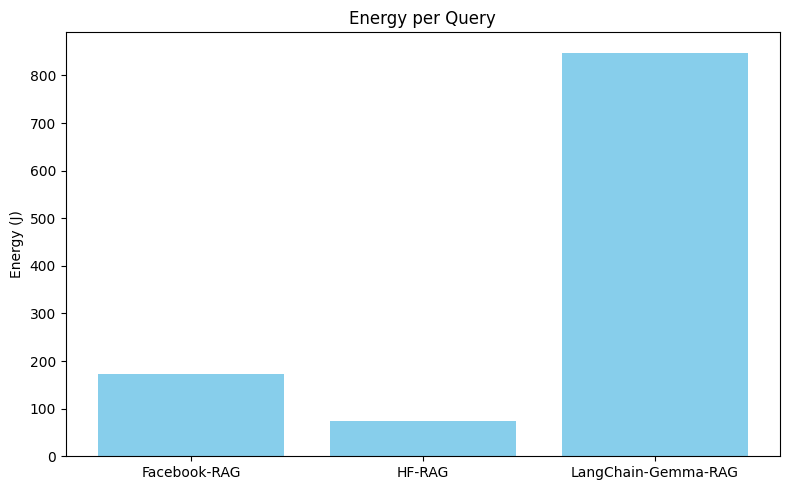

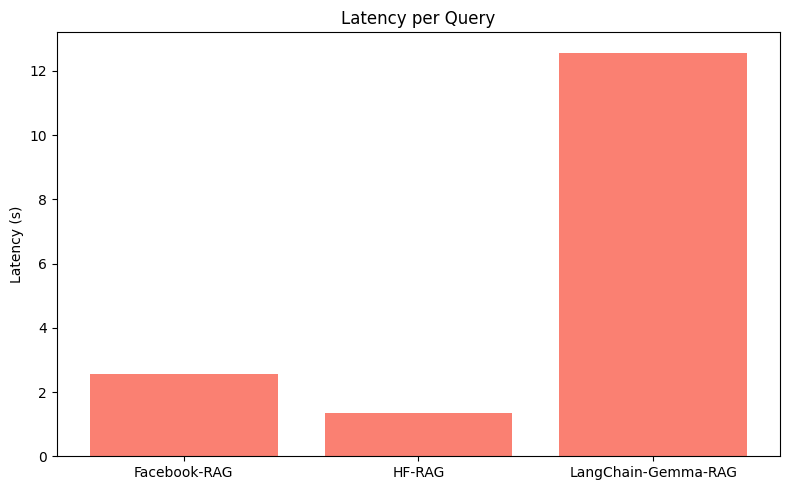

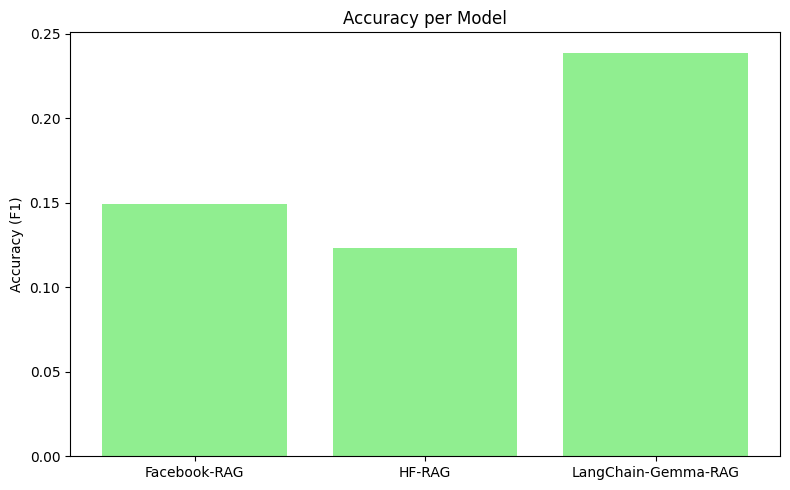

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary['model'], summary['energy_j'], color='skyblue')
plt.ylabel('Energy (J)'); plt.title('Energy per Query'); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
plt.bar(summary['model'], summary['latency_s'], color='salmon')
plt.ylabel('Latency (s)'); plt.title('Latency per Query'); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
plt.bar(summary['model'], summary['f1'], color='lightgreen')
plt.ylabel('Accuracy (F1)'); plt.title('Accuracy per Model'); plt.tight_layout(); plt.show()